In [1]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image

In [3]:
IMAGE_SIZE = [299, 299]
path_Model = "/content/gdrive/MyDrive/model_inceptionv3_mp.h5"
# path_Model = "cnn_pneumonia.h5"
path_Image1 = "/content/gdrive/MyDrive/dataset/valid/vasc/ISIC_0024475.jpg"
#path_Image2 = "/content/gdrive/MyDrive/ISIC_0024402.jpg"
#path_Image3 = "/content/gdrive/MyDrive/skin cancer detection/ham10000_images_part_2/ISIC_0029470.jpg"

In [4]:
model = tf.keras.models.load_model(path_Model,compile = True)

In [5]:
def prepare(path):
    show_img=image.load_img(path, grayscale=False, target_size=(299, 299))
    x = image.img_to_array(show_img)
    x = np.expand_dims(x, axis = 0)
    x /= 255
    plt.imshow(show_img)
    plt.show()
    return x

def predict(filename):
    disease_class=['nv','mel','bkl','bcc','akiec','vasc','df']
    custom = model.predict(prepare(filename))
    a=custom[0]
    print(custom)       
    #return disease_class[1 if a>0.6 else 0],a
    classes = np.argmax(custom, axis = 1)
    return classes

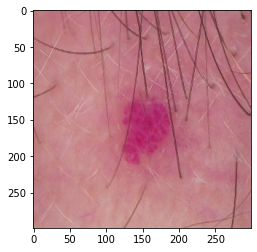

[[-2.575994   -1.3201771  -1.5203639  -2.443802   -2.2346444  -0.39084443
  -1.826498  ]]


array([5])

In [6]:
predict(path_Image1)